# 500-paper pipeline test

This notebook runs the complete ingestion flow on a small sample: select metadata from the Kaggle arXiv snapshot, download and clean sources, extract technique passages, embed papers, project and cluster them, and optionally upload the results. Source downloads are deliberately paced by arXiv, so a 500-paper run can take 25 minutes or longer.

In [1]:
from dataclasses import replace
from pathlib import Path
import os
import sys
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / "paper_clustering").is_dir():
    PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from paper_clustering.cluster import generate_clusters
from paper_clustering.data_models import ClusteredPapaer, EmbeddedPaper
from paper_clustering.embedding import embed
from paper_clustering.extract_metadata import read_metadata_archive
from paper_clustering.extract_techniques import extract_techniques_and_embed, extract_techniques_and_embed_batch
from paper_clustering.extract_text import get_paper
from paper_clustering.generate_coords import generate_umap
from paper_clustering.technique_classifier import SciBERTClassifier
from paper_clustering.upload import upload


In [2]:
MAX_PAPERS = 100
CATEGORIES = ["cs.DS", "cs.CC", "math.CO"]
KEYWORDS = ["graph"] # For example: ["coding theory", "hypergraph"]
START_DATE = datetime.date(2025, 1, 1)  # date(2020, 1, 1), or None
END_DATE = None
INCLUDE_PROOFS = True
UPLOAD_RESULTS = False  # Set True only when ready to insert into Supabase.

ARCHIVE_PATH = PROJECT_ROOT / "data" / "archive.zip"
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "weights" / "technique_classifier_checkpoint.pt"
EMBEDDING_MODEL = "nomic-ai/nomic-embed-text-v2-moe"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

assert ARCHIVE_PATH.is_file(), f"Missing metadata archive: {ARCHIVE_PATH}"
assert CLASSIFIER_WEIGHTS.is_file(), f"Missing classifier weights: {CLASSIFIER_WEIGHTS}"
print(f"Using {DEVICE}; upload enabled: {UPLOAD_RESULTS}")


Using cuda; upload enabled: False


In [3]:
selected_metadata = read_metadata_archive(
    ARCHIVE_PATH,
    start_date=START_DATE,
    end_date=END_DATE,
    categories=CATEGORIES,
    keywords=KEYWORDS,
    max_results=MAX_PAPERS,
)

assert selected_metadata, "No papers matched the configured filters."
assert len(selected_metadata) == MAX_PAPERS, (
    f"Only found {len(selected_metadata)} matching papers; adjust the filters or MAX_PAPERS."
)
arxiv_ids = [metadata.arxiv_id for metadata in selected_metadata]
print(f"Selected {len(arxiv_ids)} papers; first ID: {arxiv_ids[0]}")


Selected 100 papers; first ID: 2501.00801


In [4]:
papers = []
failed_ids = []
with requests.Session() as session:
    for metadata, arxiv_id in tqdm(zip(selected_metadata, arxiv_ids), desc="Downloading and cleaning sources"):
        try:
            paper = get_paper(session, arxiv_id, metadata=metadata, include_proofs=INCLUDE_PROOFS)
        except (requests.RequestException, ValueError) as error:
            failed_ids.append((arxiv_id, str(error)))
            continue
        if paper.sections:
            papers.append(paper)
        else:
            failed_ids.append((arxiv_id, "no usable sections"))

print(f"Usable papers: {len(papers)} / {len(arxiv_ids)}")
print(f"Failed or empty sources: {len(failed_ids)}")
assert papers, "No usable source documents were extracted."


Usable papers: 98 / 100
Failed or empty sources: 2


In [5]:
from sentence_transformers import SentenceTransformer

classifier = SciBERTClassifier(weights_path=CLASSIFIER_WEIGHTS).to(DEVICE)
encoder = SentenceTransformer(
    EMBEDDING_MODEL,
    trust_remote_code=True,
    device=DEVICE,
)

area_texts = [
    f"{paper.metadata.title}\n\n{paper.metadata.abstract}"
    for paper in papers
]
area_vectors = embed(area_texts, encoder, batch_size=8, prompt="clustering", device=DEVICE)
embedded_papers = extract_techniques_and_embed_batch(papers, classifier, encoder, areas=area_vectors)
# embedded_papers = []
# for paper, area_vector in tqdm(
#     zip(papers, area_vectors, strict=True),
#     total=len(papers),
#     desc="Extracting and embedding techniques",
# ):
#     technique_paper = extract_techniques_and_embed(paper, classifier, encoder)
#     embeddings = replace(
#         technique_paper.embeddings,
#         area_vector=np.asarray(area_vector),
#     )
#     embedded_papers.append(EmbeddedPaper(paper=paper, embeddings=embeddings))

print(f"Embedded {len(embedded_papers)} papers")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/alfred/.cache/huggingface/modules/transformers_modules/nomic_hyphen_ai/nomic_hyphen_bert_hyphen_2048/7710840340a098

Embedded 98 papers


In [6]:
from umap import UMAP

area_matrix = np.asarray([paper.embeddings.area_vector for paper in embedded_papers])
reducer = UMAP(n_components=2, metric="cosine", random_state=42).fit(area_matrix)
coordinates = generate_umap(embedded_papers, reducer)
cluster_labels = generate_clusters(list(area_matrix))
clustered_papers = [
    ClusteredPapaer(embedded_paper=paper, coords=coords, cluster_label=label)
    for paper, coords, label in zip(embedded_papers, coordinates, cluster_labels, strict=True)
]

results = pd.DataFrame(
    {
        "arxiv_id": [item.embedded_paper.paper.metadata.arxiv_id for item in clustered_papers],
        "title": [item.embedded_paper.paper.metadata.title for item in clustered_papers],
        "category": [item.embedded_paper.paper.metadata.primary_category for item in clustered_papers],
        "cluster": [item.cluster_label for item in clustered_papers],
        "x": [item.coords[0] for item in clustered_papers],
        "y": [item.coords[1] for item in clustered_papers],
        "technique_count": [len(item.embedded_paper.embeddings.passages) for item in clustered_papers],
    }
)
print(results["cluster"].value_counts().sort_index())
results.head()


/home/alfred/miniconda3/envs/paper-clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
-1    85
 0     6
 1     7
Name: count, dtype: int64


/home/alfred/miniconda3/envs/paper-clustering/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,arxiv_id,title,category,cluster,x,y,technique_count
0,2501.00801,Density Hajnal--Szemer\'{e}di theorem for cliques of size four,math.CO,-1,14.309625,0.121035,3
1,2501.00926,Differentially Private Matchings,cs.DS,-1,16.983942,1.443323,3
2,2501.00951,Pseudorandom quantum authentication,quant-ph,-1,17.123301,1.005993,0
3,2501.00991,Twin-width one,cs.DM,-1,15.081437,0.444738,3
4,2501.00998,Transversal Hamilton cycles in digraph collections,math.CO,-1,14.116910,0.374831,3


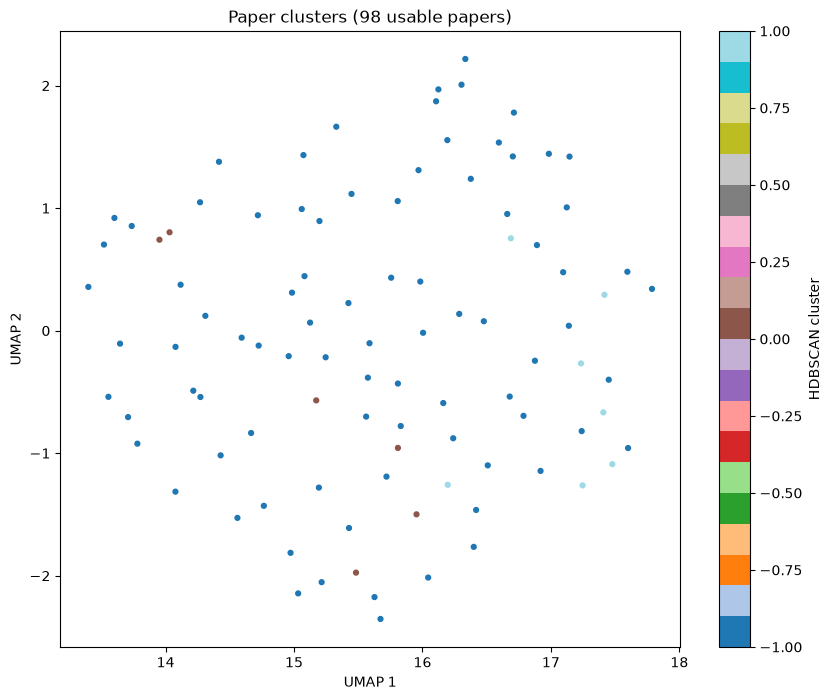

In [7]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(results["x"], results["y"], c=results["cluster"], s=12, cmap="tab20")
plt.colorbar(scatter, label="HDBSCAN cluster")
plt.title(f"Paper clusters ({len(clustered_papers)} usable papers)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()


In [8]:
if UPLOAD_RESULTS:
    from dotenv import load_dotenv
    from supabase import create_client

    load_dotenv(PROJECT_ROOT / ".env")
    supabase_url = os.environ["SUPABASE_URL"]
    supabase_key = os.environ["SUPABASE_KEY"]
    response = upload(clustered_papers, create_client(supabase_url, supabase_key))
    print(f"Uploaded {len(clustered_papers)} papers.")
else:
    print("Upload skipped. Set UPLOAD_RESULTS = True to complete the database-write step.")


Upload skipped. Set UPLOAD_RESULTS = True to complete the database-write step.


## Technique similarity queries

Run three in-memory nearest-neighbour queries over the extracted technique vectors. This validates the same cosine-similarity behavior used by the database ANN query, without requiring an upload.

In [9]:
# I don't actually understand this code. Run with caution.
passage_records = [
    (paper.paper.metadata.arxiv_id, passage, vector)
    for paper in embedded_papers
    for passage, vector in zip(
        paper.embeddings.passages, paper.embeddings.vectors, strict=True
    )
]
assert passage_records, "No technique passages were extracted, so queries cannot run."

passage_ids = np.array([record[0] for record in passage_records])
passage_texts = [record[1] for record in passage_records]
passage_vectors = np.asarray([record[2] for record in passage_records])
title_by_id = {paper.paper.metadata.arxiv_id: paper.paper.metadata.title for paper in embedded_papers}
query_ids = list(dict.fromkeys(passage_ids))
query_ids = [query_ids[index] for index in np.linspace(0, len(query_ids) - 1, min(3, len(query_ids)), dtype=int)]

def similar_papers(query_id, k=5):
    query_indices = np.flatnonzero(passage_ids == query_id)
    similarities = passage_vectors[query_indices] @ passage_vectors.T
    best_score_by_paper = {}
    best_query_passage_by_paper = {}
    best_passage_by_paper = {}
    for query_position, target_position in zip(*np.unravel_index(np.argsort(-similarities, axis=None), similarities.shape)):
        target_id = passage_ids[target_position]
        if target_id == query_id or target_id in best_score_by_paper:
            continue
        best_score_by_paper[target_id] = float(similarities[query_position, target_position])
        best_query_passage_by_paper[target_id] = passage_texts[query_indices[query_position]]
        best_passage_by_paper[target_id] = passage_texts[target_position]
        if len(best_score_by_paper) == k:
            break
    return pd.DataFrame(
        {
            "arxiv_id": list(best_score_by_paper),
            "similarity": list(best_score_by_paper.values()),
            "title": [title_by_id[target_id] for target_id in best_score_by_paper],
            "query_passage": [best_query_passage_by_paper[target_id] for target_id in best_score_by_paper],
            "matching_passage": [best_passage_by_paper[target_id] for target_id in best_score_by_paper],
        }
    )

for query_id in query_ids:
    print(f"\nQuery: {query_id} — {title_by_id[query_id]}")
    display(similar_papers(query_id))



Query: 2501.00801 — Density Hajnal--Szemer\'{e}di theorem for cliques of size four


arxiv_id  similarity  \
0  2501.03216    0.668905   
1  2501.04297    0.662259   
2  2501.02543    0.633077   
3  2501.06463    0.624695   
4  2501.03439    0.589108   

                                                                                     title  \
0                       A note on improved bounds for hypergraph rainbow matching problems   
1                                        Two Distinct Eigenvalues from a New Graph Product   
2                           ($P_2+P_4$, $K_4-e$)-free graphs are nearly $\omega$-colorable   
3  Two Proofs of a Structural Theorem of Decreasing Minimization on Integrally Convex Sets   
4                                                             On the anti-Ramsey threshold   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 


Query: 2501.04224 — Modular Counting CSP: Reductions and Algorithms


,arxiv_id,similarity,title,query_passage,matching_passage
0,2501.03789,0.563002,Structures preserved by primitive actions of $S_\omega$,"Section: Remedies Text: Multi-sorted structures and p -rigidity. We start with applying a well-known framework of multi-sorted relational structures to modular counting. While multi-sorted structures is a standard tool in the study of decision CSPs, it usually only used to simplify arguments and streamline algorithms. Here we use this framework in a more fundamental way, to strengthen the main (hypothetical) tractability condition","Section: Contributions Text: In our proof we make use of structural Ramsey theory. A method using Ramsey theory and canonical functions was developed and used in earlier papers; see [BP-reductsRamsey] for an introduction. However, it can be observed that this method does not scale well, in the sense that for more complicated structures, the number of canonical functions and the number of cases that needs to be considered in a combinatorial analysis grows tremendously. In our case, it is furthermore unclear how to perform such an analysis for bJ(k) for arbitrary k"
1,2501.01599,0.545305,Reflexive Digraph Reconfiguration by Orientation Strings,"Section: Remedies Text: Let us consider again the structure cT_p introduced in the beginning of Section and discover that when considered as a multi-sorted structure cT_p is not p -rigid, and therefore can be transformed so that the corresponding modular CSP is solvable in polynomial time. The idea is, given an instance cG of ghomk p(cT_p), to use some preprocessing algorithm (such as local propagation or a solution algorithm for the decision CSP) to reduce possible range of vertices from cG under homomorphisms. We then refine the instance by replacing cT_p with a multi-sorted structure in such a way that every possible range of a vertex from cG becomes a set of a distinct type. Now, since automorphisms of a multi-sorted structure may act differently on different types, the refined structure may have a richer automorphism group. For instance, for the refinement of cT_p the sets T_p and (0) have different types, and an automorphism of such a structure may act differently on these sets and no longer has to have 0 as a fixed point when acting on T_p","Section: Tools for reducing to monotone homomorphisms Text: For a homomorphism phi in Hom(C, D), a subpath P =c_adots c _b of C is a cutback if its increase is 0 (so phi(c_a) = phi(c_b) ) and the increase of c_a dots c_i is negative for all i in (a+1, dots, b-1). In Figure, the path v_0v_1v_2 is a cutback, to make the shown map monotone, we will want to push v_1 up to where v_0 and v_2 are. This is what the next lemma lets us do"
2,2501.00991,0.533716,Twin-width one,"Section: Remedies Text: Let us consider again the structure cT_p introduced in the beginning of Section and discover that when considered as a multi-sorted structure cT_p is not p -rigid, and therefore can be transformed so that the corresponding modular CSP is solvable in polynomial time. The idea is, given an instance cG of ghomk p(cT_p), to use some preprocessing algorithm (such as local propagation or a solution algorithm for the decision CSP) to reduce possible range of vertices from cG under homomorphisms. We then refine the instance by replacing cT_p with a multi-sorted structure in such a way that every possible range of a vertex from cG becomes a set of a distinct type. Now, since automorphisms of a multi-sorted structure may act differently on different types, the refined structure may have a richer automorphism group. For instance, for the refinement of cT_p the sets T_p and (0) have different types, and an automorphism of such a structure may act differently on these sets and no longer has to have 0 as a fixed point when acting on T_p","Section: Our results Text: Interestingly, our structural analysis via the permutation diagrams allows us to avoid a characterisation by forbidden induced subgraphs. Moreover


Query: 2501.06935 — Feedback Arc Sets and Feedback Arc Set Decompositions in Weighted and Unweighted Oriented Graphs


,arxiv_id,similarity,title,query_passage,matching_passage
0,2501.05968,0.611926,Oriented discrepancy of Hamilton cycles in oriented graphs satisfying Ore-type condition,"Section: Proving fasd(4,3)=3 Text: Let D be an oriented graph and let T' be a good triple of D-v for some v in V(D). By inserting v into T' we mean inserting v into every ordering of T' in such a way that we obtain a good triple T of D. We say that sigma' is a subordering of sigma if sigma' can be obtained from sigma by deleting vertices. We write sigma' leq sigma if sigma' is a subordering of sigma","Section: Proof of Theorem Text: start-of-lemma: Let D be an oriented graph which contains an oriented path P and a set of vertices K disjoint from V(P), such that V(P)subseteq N(v) for each vin K. If |V(P)|ge |K|+2, then D contains an oriented path P' with V(P')=V(P)cup K and same initial and terminal vertices as P, satisfying sigma^+(P')ge sigma^+(P). Similarly, an oriented path P"" satisfying sigma^-(P"") ge sigma^-(P) also exists. end-of-lemma"
1,2501.02543,0.549380,"($P_2+P_4$, $K_4-e$)-free graphs are nearly $\omega$-colorable","Section: Proving fasd(4,3)=3 Text: Let D be an oriented graph and let T' be a good triple of D-v for some v in V(D). By inserting v into T' we mean inserting v into every ordering of T' in such a way that we obtain a good triple T of D. We say that sigma' is a subordering of sigma if sigma' can be obtained from sigma by deleting vertices. We write sigma' leq sigma if sigma' is a subordering of sigma","Section: G contains an F Text: start-of-lemma: If G contains an H_2, then chi(G) = 4. end-of-lemma start-of-proof: Suppose G contains an H_2. We label such an H_2 as shown in Figure. Clearly a, bin A_1 and a', b' in A_2. We may assume that G is H_1 -free, by. Further we claim the following. Proof of. By, G[A_i cup A_jcup T] is perfect, for ineq j. Moreover, since G is H_1 -free, we have omega(G[A_i])leq 2 for each i, and so by, G[A_i cup A_j] is K_3 -free, for ineq j. Thus for ineq j, G[A_i cup A_j] is a perfect K_3 -free graph and so chi(G[A_i cup A_j])leq 2. Then since (Csetminus (v_i, v_j)) is anticomplete to A_i cup A_j, we see that chi(G[A_i cup A_jcup (Csetminus (v_i,v_j))])= 2. This proves. sq Proof of. Suppose to the contrary that there is a K_3 in G[A_1 cup A_2 cup T] with vertices, say x, y and z, which has two vertices from A_1 cup A_2, say x and y. Then by,, and by symmetry, we have two cases: (i) x=a, y=a' and zin T, and (ii) xin A_1, yin A_2setminus (a', b') and zin T. First suppose that x=a, y=a' and zin T. Then since (v_3, v_4, b, x, y, b') does not induce a P_2 + P_4, we have bb' in E(G), by. Again by, we have zb, zb'notin E(G). But then (v_3, v_4, z, x, b, b') induces a P_2 + P_4 which is a contradiction. Next suppose that xin A_1, yin A_2setminus (a', b') and zin T. Then since (a', b', y, x, v_1, v_4) does not induce a P_2 + P_4, by using we may assume that xa'in E(G) and xb'notin E(G). But then (v_3, v_4, b', a', x, y) induces a P_2 + P_4 which is a contradiction. So the claim holds. sq Proof of. Suppose to the contrary that G[A_1 cup A_2 cup T] contains a K_3 with vertices, say x, y and z. By, and, we may assume that xin A_1 and y, zin T. First suppose that x = a. Then by, we have by, bznotin E(G), and we may assume that ba'notin E(G), and then since (y, z, b, v_1, v_2, a') does not induce a P_2 + P_4, we may assume that ya'in E(G). But then since (x, y, a') does not induce a K_3 in G[A_1 cup A_2 cup T] which has two vertices from A_1 cup A_2, we have xa'notin E(G) (by ), and then (v_3, v_4, b, x, y, a') induces a P_2 + P_4 which is a contradiction; so we may assume that xin A_1setminus (a, b), by. By, we may assume that aa'notin E(G). Then since (y, z, a, v_1, v_2, a') does not induce a P_2+P_4, we may assume that yain E(G) or ya'in E(G). If yain E(G), then (v_3, v_4, x, y, a, b) induces a P_2+P_4 (by ); so we may assume that yanotin E(G) and hence ya'in E(G). Then since (x, y, a') does not induce a K_3 in G[A_1 cu